# Time Series Forecasting with Seq2Seq Models

In this notebook, we will build a simple time series forecasting model using PyTorch.

Goal:

```text
Use the last 21 days of store data -> predict the next 7 days of sales
```

We will start from this CSV file:

```text
daily_store_sales_raw.csv
```

The CSV has one row per day:

```text
date, sales, discount, is_weekend, is_holiday
```

## What We Will Do

1. Load the sales CSV
2. Plot the sales data
3. Split the data by time
4. Scale the features
5. Create sliding windows
6. Build simple baseline models
7. Build a Seq2Seq GRU model
8. Train the model
9. Check test error
10. Plot one 7-day forecast

Main idea:

```text
past data -> encoder -> decoder -> future sales
```


## 1. Imports and Setup

We will use:

- `pandas` and `numpy` for data work
- `matplotlib` for plots
- `StandardScaler` for scaling
- `torch` for the deep learning model

We also set random seeds so the results are easier to repeat.


In [1]:
# -----------------------------------------------------------------------------
# This cell imports the libraries and sets random seeds.
# Random seeds make the notebook easier to reproduce.
# -----------------------------------------------------------------------------
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.style.use("seaborn-v0_8-whitegrid")


## 2. Load the CSV File

We start by loading the sales data from CSV.

The target column is `sales`. This is what we want to predict.

The CSV also has extra useful columns:

- `date`: the day of the record
- `discount`: discount planned for that day
- `is_weekend`: 1 if the day is Saturday or Sunday, else 0
- `is_holiday`: 1 if the day is a holiday, else 0

For time series, order is very important. So after loading the CSV, we sort by `date`.

We also create two new weekday features:

```text
day_sin, day_cos
```

These help the model understand the weekly cycle.


In [2]:
# -----------------------------------------------------------------------------
# This cell loads the CSV, checks the data, and creates weekday features.
# -----------------------------------------------------------------------------
csv_candidates = [
    Path("daily_store_sales_raw.csv"),
    Path("27_time_series_forecasting_seq2seq") / "daily_store_sales_raw.csv",
]

DATA_PATH = next((path for path in csv_candidates if path.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find daily_store_sales_raw.csv. "
        "Place it beside this notebook or run the notebook from the repository root."
    )

# Parse date as a real datetime column.
df = pd.read_csv(DATA_PATH, parse_dates=["date"])

required_cols = ["date", "sales", "discount", "is_weekend", "is_holiday"]
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# Keep the columns we need.
df = df[required_cols].copy()

# Convert model columns to numbers.
numeric_cols = ["sales", "discount", "is_weekend", "is_holiday"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="raise")

# Store flags as 0/1 integers.
df["is_weekend"] = df["is_weekend"].astype(int)
df["is_holiday"] = df["is_holiday"].astype(int)

# Sort by date before splitting or making windows.
df = df.sort_values("date").reset_index(drop=True)

if df[required_cols].isna().any().any():
    raise ValueError("The CSV contains missing values. Please clean the file before modeling.")

if df["date"].duplicated().any():
    raise ValueError("The CSV contains duplicate dates. Each date should appear once.")

expected_dates = pd.date_range(df["date"].min(), df["date"].max(), freq="D")
if not np.array_equal(df["date"].values, expected_dates.values):
    raise ValueError("The CSV should contain one row per calendar day without gaps.")

# Convert weekday into a weekly cycle.
weekday = df["date"].dt.dayofweek
weekly_cycle = 2 * np.pi * weekday / 7
df["day_sin"] = np.sin(weekly_cycle)
df["day_cos"] = np.cos(weekly_cycle)

print("Loaded CSV from:", DATA_PATH)
print("Rows:", len(df))
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())
print("Model columns:", list(df.columns))

df.head(10)


Loaded CSV from: daily_store_sales_raw.csv
Rows: 260
Date range: 2026-01-01 to 2026-09-17
Model columns: ['date', 'sales', 'discount', 'is_weekend', 'is_holiday', 'day_sin', 'day_cos']


,date,sales,discount,is_weekend,is_holiday,day_sin,day_cos
0,2026-01-01,81.490142,0.0,0,0,0.433884,-0.900969
1,2026-01-02,85.959859,0.0,0,0,-0.433884,-0.900969
2,2026-01-03,99.982489,0.0,1,0,-0.974928,-0.222521
3,2026-01-04,98.400159,0.0,1,0,-0.781831,0.623490
4,2026-01-05,76.306470,0.0,0,0,0.000000,1.000000
5,2026-01-06,72.098166,0.0,0,0,0.781831,0.623490
6,2026-01-07,79.202987,0.0,0,0,0.974928,-0.222521
7,2026-01-08,83.142304,0.0,0,0,0.433884,-0.900969
8,2026-01-09,85.806229,0.0,0,0,-0.433884,-0.900969
9,2026-01-10,100.507103,0.0,1,0,-0.974928,-0.222521


### Findings From the Loaded Data

- The CSV loaded correctly with **260 daily rows**.
- The date range is **2026-01-01 to 2026-09-17**.
- The final modeling data has **7 columns**: the 5 raw columns plus `day_sin` and `day_cos`.
- The weekday features repeat every 7 days, which helps the model learn weekly behavior.


### Note

This is the dataset we will use.

Each row is one day. The rows must stay in date order.

The model will use past `sales` plus known features like `discount`, `is_weekend`, and `is_holiday` to predict future sales.


## 3. Plot the Time Series

Before building a model, always plot the data.

Look for:

- Trend
- Weekly pattern
- Spikes
- Noise


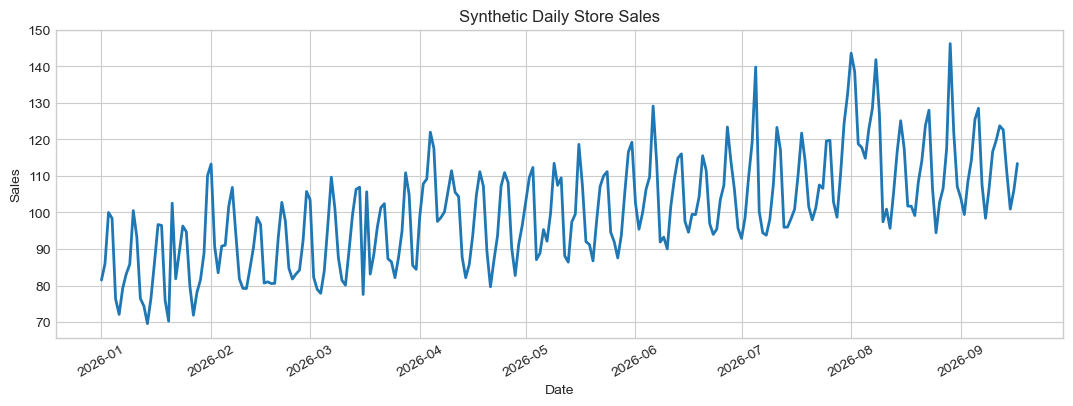

In [3]:
# -----------------------------------------------------------------------------
# This cell plots the full sales history.
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df["date"], df["sales"], color="#1f77b4", linewidth=2)
ax.set_title("Synthetic Daily Store Sales")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
plt.xticks(rotation=30)
plt.show()


### Findings From the Full Sales Plot

- Sales show an upward trend over time.
- The line has repeated ups and downs, which suggests weekly seasonality.
- Some peaks are much higher than nearby days. These can come from weekends, holidays, or discount periods.
- Sales range from about **70** to about **146** units.


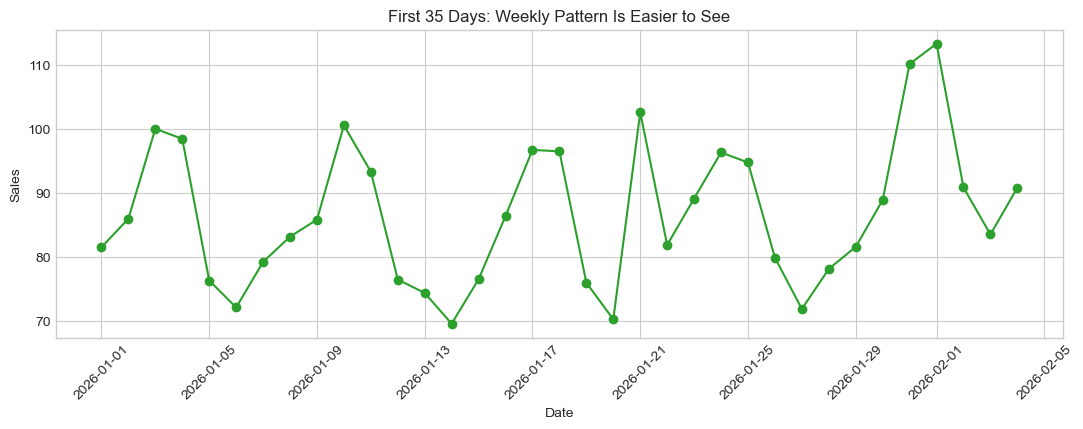

In [4]:
# -----------------------------------------------------------------------------
# This cell zooms into the first 35 days to show weekly pattern.
# -----------------------------------------------------------------------------
# Look at the first 35 days to make weekly seasonality easier to see.
preview = df.iloc[:35]

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(preview["date"], preview["sales"], marker="o", color="#2ca02c")
ax.set_title("First 35 Days: Weekly Pattern Is Easier to See")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
plt.xticks(rotation=45)
plt.show()


### Findings From the First 35 Days

- The weekly pattern is easier to see in this smaller view.
- Weekend sales are usually higher than weekday sales.
- The first 35 days range from about **70** to **113** sales units.
- This supports using weekday features and a 7-day seasonal baseline.


## 4. Define the Forecasting Problem

Before modeling, we must define the task.

For this notebook:

```text
target   = sales
lookback = 21 days
horizon  = 7 days
```

So every training example means:

```text
previous 21 days -> next 7 days
```

The input features are:

```text
sales, discount, is_weekend, is_holiday, day_sin, day_cos
```

The model predicts only future `sales`.


In [5]:
# -----------------------------------------------------------------------------
# This cell defines the forecasting setup.
# LOOKBACK = past days used as input.
# HORIZON = future days to predict.
# -----------------------------------------------------------------------------
LOOKBACK = 21
HORIZON = 7
TARGET_COL = "sales"

feature_cols = ["sales", "discount", "is_weekend", "is_holiday", "day_sin", "day_cos"]
target_col_index = feature_cols.index(TARGET_COL)

print("Feature columns:", feature_cols)
print("Lookback:", LOOKBACK)
print("Horizon:", HORIZON)


Feature columns: ['sales', 'discount', 'is_weekend', 'is_holiday', 'day_sin', 'day_cos']
Lookback: 21
Horizon: 7


### Findings From the Forecast Setup

- The model uses **6 input features** at each time step.
- `LOOKBACK = 21`, so the model reads the previous 21 days.
- `HORIZON = 7`, so the model predicts the next 7 days.
- The input has many features, but the output predicts only future `sales`.


## 5. Split Train, Validation, and Test by Time

For time series, do not randomly split the rows.

Correct split:

```text
old data -> train
middle data -> validation
latest data -> test
```

Why?

Because in real forecasting, we train on the past and predict the future.

Random splitting can leak future information into training.


In [6]:
# -----------------------------------------------------------------------------
# This cell splits the data by time: train first, validation next, test last.
# -----------------------------------------------------------------------------
n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print("Train period:", train_df["date"].min().date(), "to", train_df["date"].max().date(), train_df.shape)
print("Val period:  ", val_df["date"].min().date(), "to", val_df["date"].max().date(), val_df.shape)
print("Test period: ", test_df["date"].min().date(), "to", test_df["date"].max().date(), test_df.shape)


Train period: 2026-01-01 to 2026-07-01 (182, 7)
Val period:   2026-07-02 to 2026-08-09 (39, 7)
Test period:  2026-08-10 to 2026-09-17 (39, 7)


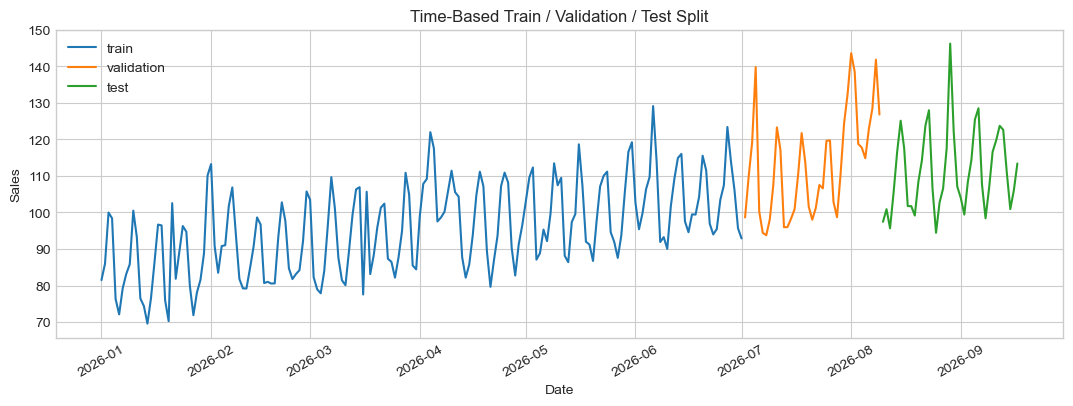

In [7]:
# -----------------------------------------------------------------------------
# This cell plots the train, validation, and test periods.
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(train_df["date"], train_df["sales"], label="train", color="#1f77b4")
ax.plot(val_df["date"], val_df["sales"], label="validation", color="#ff7f0e")
ax.plot(test_df["date"], test_df["sales"], label="test", color="#2ca02c")
ax.set_title("Time-Based Train / Validation / Test Split")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
ax.legend()
plt.xticks(rotation=30)
plt.show()


### Findings From the Time Split

- The split keeps the original time order.
- Training data runs from **2026-01-01 to 2026-07-01**.
- Validation data runs from **2026-07-02 to 2026-08-09**.
- Test data runs from **2026-08-10 to 2026-09-17**.
- This matches the real forecasting setup: train on the past, test on the future.


## 6. Scale Features Using Train Data Only

Neural networks usually train better when numbers are scaled.

Important rule:

```text
fit scaler only on train data
use the same scaler for validation and test data
```

This avoids data leakage.

Standard scaling means:

```text
scaled_value = (value - train_mean) / train_std
```


In [8]:
# -----------------------------------------------------------------------------
# This cell scales features using train data only.
# -----------------------------------------------------------------------------
scaler = StandardScaler()

train_scaled = train_df.copy()
val_scaled = val_df.copy()
test_scaled = test_df.copy()

train_scaled[feature_cols] = scaler.fit_transform(train_df[feature_cols])
val_scaled[feature_cols] = scaler.transform(val_df[feature_cols])
test_scaled[feature_cols] = scaler.transform(test_df[feature_cols])

sales_mean = scaler.mean_[target_col_index]
sales_std = scaler.scale_[target_col_index]

print("Sales mean from train only:", round(sales_mean, 3))
print("Sales std from train only: ", round(sales_std, 3))


Sales mean from train only: 95.51
Sales std from train only:  12.098


### Findings From Scaling

- The scaler was fitted only on the training period.
- Training sales mean is about **95.51**.
- Training sales standard deviation is about **12.10**.
- These values are saved so predictions can be converted back to normal sales units later.


## 7. Create Sliding Windows

The raw data is one long time series.

The model needs many examples like this:

```text
X = previous 21 days of features
y = next 7 days of sales
```

Shapes:

```text
X shape = (batch, 21, number_of_features)
y shape = (batch, 7, 1)
```

The dataset class creates these windows automatically.

Example:

```text
rows 0 to 20  -> input X
rows 21 to 27 -> target y
```

Then it moves forward by one day and creates the next window.


In [9]:
# -----------------------------------------------------------------------------
# This cell creates PyTorch datasets using sliding windows.
# -----------------------------------------------------------------------------
class TimeSeriesWindowDataset(Dataset):
    def __init__(self, frame, feature_cols, target_col, lookback, horizon):
        self.values = frame[feature_cols].values.astype(np.float32)
        self.target_index = feature_cols.index(target_col)
        self.lookback = lookback
        self.horizon = horizon

    def __len__(self):
        return len(self.values) - self.lookback - self.horizon + 1

    def __getitem__(self, idx):
        x_start = idx
        x_end = idx + self.lookback
        y_end = x_end + self.horizon

        x = self.values[x_start:x_end]
        # y contains only the next 7 sales values, shape: (7, 1).
        y = self.values[x_end:y_end, self.target_index:self.target_index + 1]

        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


train_dataset = TimeSeriesWindowDataset(train_scaled, feature_cols, TARGET_COL, LOOKBACK, HORIZON)
val_dataset = TimeSeriesWindowDataset(val_scaled, feature_cols, TARGET_COL, LOOKBACK, HORIZON)
test_dataset = TimeSeriesWindowDataset(test_scaled, feature_cols, TARGET_COL, LOOKBACK, HORIZON)

print("Train windows:", len(train_dataset))
print("Val windows:  ", len(val_dataset))
print("Test windows: ", len(test_dataset))

x0, y0 = train_dataset[0]
print("One X shape:", tuple(x0.shape))
print("One y shape:", tuple(y0.shape))


Train windows: 155
Val windows:   12
Test windows:  12
One X shape: (21, 6)
One y shape: (7, 1)


### Findings From Sliding Windows

- The training split creates **155 windows**.
- Validation and test each create **12 windows**.
- One input sample has shape **(21, 6)**: 21 days and 6 features.
- One target sample has shape **(7, 1)**: 7 future sales values.


### Sliding Window Diagram

The next cell shows how windows move through time.

Blue = input days.

Orange = future days to predict.


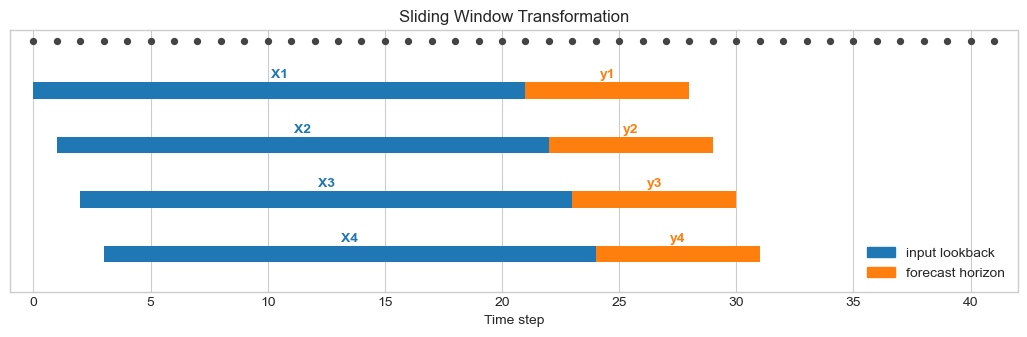

In [10]:
# -----------------------------------------------------------------------------
# This cell draws a simple sliding-window diagram.
# -----------------------------------------------------------------------------
def draw_sliding_windows(lookback=LOOKBACK, horizon=HORIZON, n_points=42, n_windows=4):
    fig, ax = plt.subplots(figsize=(13, 3.4))
    ax.set_title("Sliding Window Transformation")
    ax.set_xlabel("Time step")
    ax.set_yticks([])
    ax.set_xlim(-1, n_points)
    ax.set_ylim(-0.8, n_windows)

    ax.scatter(range(n_points), [n_windows - 0.2] * n_points, s=18, color="#444444")

    for i in range(n_windows):
        y = n_windows - 1 - i
        x_start = i
        x_end = x_start + lookback
        y_end = x_end + horizon

        ax.broken_barh([(x_start, lookback)], (y - 0.25, 0.3), facecolors="#1f77b4")
        ax.broken_barh([(x_end, horizon)], (y - 0.25, 0.3), facecolors="#ff7f0e")
        ax.text(x_start + lookback / 2, y + 0.12, f"X{i+1}", ha="center", color="#1f77b4", weight="bold")
        ax.text(x_end + horizon / 2, y + 0.12, f"y{i+1}", ha="center", color="#ff7f0e", weight="bold")

    ax.legend(
        handles=[
            plt.Rectangle((0, 0), 1, 1, color="#1f77b4", label="input lookback"),
            plt.Rectangle((0, 0), 1, 1, color="#ff7f0e", label="forecast horizon"),
        ],
        loc="lower right"
    )
    plt.show()


draw_sliding_windows()


## 8. Create DataLoaders

`DataLoader` gives data to the model in small batches.

We shuffle only the training windows.

Validation and test data are not shuffled, so the order stays easy to inspect.


In [11]:
# -----------------------------------------------------------------------------
# This cell creates DataLoaders for batch training and evaluation.
# -----------------------------------------------------------------------------
BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

batch_x, batch_y = next(iter(train_loader))
print("Batch X:", tuple(batch_x.shape))
print("Batch y:", tuple(batch_y.shape))


Batch X: (16, 21, 6)
Batch y: (16, 7, 1)


### Findings From DataLoaders

- Each training batch has shape **(16, 21, 6)**.
- Each target batch has shape **(16, 7, 1)**.
- This confirms that the batch data matches the Seq2Seq model input and output shapes.


## 9. Baseline Forecasts

Before using deep learning, compare with simple methods.

We will use:

1. **Naive**: repeat the last sales value
2. **Seasonal naive**: repeat the last 7 sales values
3. **Moving average**: repeat the average of the last 7 sales values

A deep learning model should beat these simple baselines.


In [12]:
# -----------------------------------------------------------------------------
# This cell creates simple baseline forecasts and scores them.
# -----------------------------------------------------------------------------

# StandardScaler scales values like this:
# scaled_sales = (sales - sales_mean) / sales_std
# So to convert back:
# sales = scaled_sales * sales_std + sales_mean
def inverse_sales(scaled_sales):
    return scaled_sales * sales_std + sales_mean


def collect_dataset_tensors(dataset):
    xs = []
    ys = []
    for i in range(len(dataset)):
        x, y = dataset[i]
        xs.append(x)
        ys.append(y)
    return torch.stack(xs), torch.stack(ys)


def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


x_test_all, y_test_all = collect_dataset_tensors(test_dataset)

# Baseline 1: repeat last observed target value across the whole horizon.
last_value = x_test_all[:, -1:, target_col_index:target_col_index + 1]
naive_pred_scaled = last_value.repeat(1, HORIZON, 1)

# Baseline 2: for a 7-day horizon, repeat the last 7 observed target values.
seasonal_pred_scaled = x_test_all[:, -HORIZON:, target_col_index:target_col_index + 1]

# Baseline 3: repeat the mean of the last 7 target values.
ma_value = x_test_all[:, -HORIZON:, target_col_index:target_col_index + 1].mean(dim=1, keepdim=True)
ma_pred_scaled = ma_value.repeat(1, HORIZON, 1)

# Convert everything back to original sales units before metric calculation.
y_test_actual = inverse_sales(y_test_all.numpy())
naive_pred = inverse_sales(naive_pred_scaled.numpy())
seasonal_pred = inverse_sales(seasonal_pred_scaled.numpy())
ma_pred = inverse_sales(ma_pred_scaled.numpy())

baseline_scores = pd.DataFrame({
    "model": ["naive", "seasonal_naive", "moving_average_7"],
    "MAE": [mae(y_test_actual, naive_pred), mae(y_test_actual, seasonal_pred), mae(y_test_actual, ma_pred)],
    "RMSE": [rmse(y_test_actual, naive_pred), rmse(y_test_actual, seasonal_pred), rmse(y_test_actual, ma_pred)],
})

baseline_scores


,model,MAE,RMSE
0,naive,11.046169,13.436134
1,seasonal_naive,5.664824,7.459758
2,moving_average_7,8.456865,9.601283


### Findings From Baselines

- `seasonal_naive` is the strongest baseline with **MAE = 5.66** and **RMSE = 7.46**.
- `moving_average_7` is weaker with **MAE = 8.46**.
- `naive` is the weakest with **MAE = 11.05**.
- The strong seasonal baseline tells us the data has a clear weekly pattern.


## 10. Seq2Seq Diagram

Seq2Seq has two main parts:

```text
Encoder: reads the past
Decoder: predicts the future
```

The decoder predicts one future day at a time.


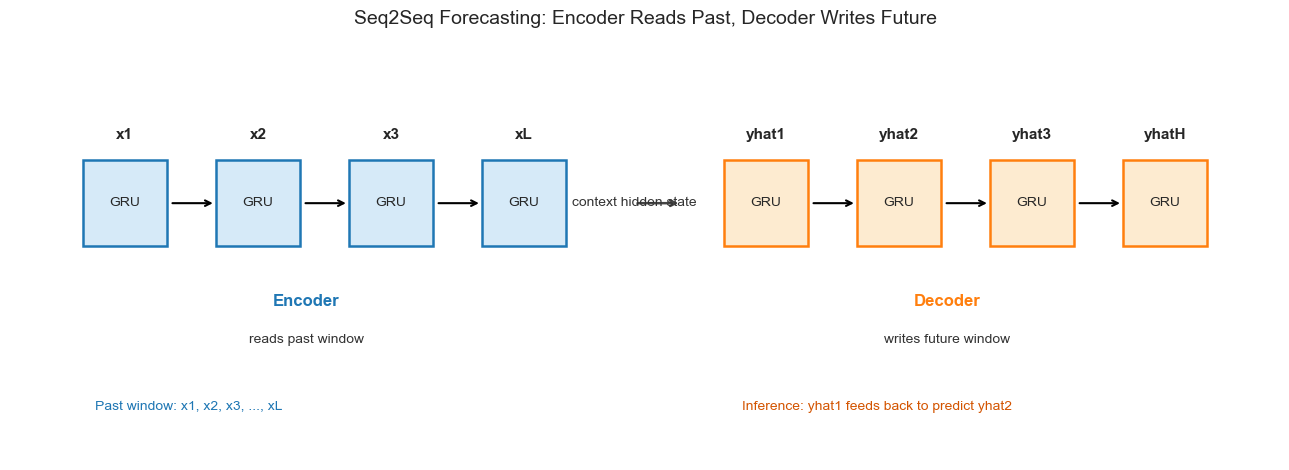

In [13]:
# -----------------------------------------------------------------------------
# This cell draws a simple Seq2Seq architecture diagram.
# -----------------------------------------------------------------------------
def draw_seq2seq_diagram():
    fig, ax = plt.subplots(figsize=(13, 4.8))

    # Important: custom patches do not always update the visible plot area.
    # These limits make sure every box, arrow, and label is inside the canvas.
    ax.set_xlim(0, 10.5)
    ax.set_ylim(1.0, 3.9)
    ax.axis("off")
    ax.set_title("Seq2Seq Forecasting: Encoder Reads Past, Decoder Writes Future", fontsize=14, pad=16)

    # Encoder boxes: x1, x2, x3, ..., xL
    enc_x = [0.6, 1.7, 2.8, 3.9]
    for i, x in enumerate(enc_x, start=1):
        ax.add_patch(plt.Rectangle((x, 2.5), 0.7, 0.6, fill=True, color="#d6eaf8", ec="#1f77b4", lw=1.8))
        label = f"x{i}" if i < 4 else "xL"
        ax.text(x + 0.35, 3.28, label, ha="center", va="center", fontsize=11, weight="bold")
        ax.text(x + 0.35, 2.8, "GRU", ha="center", va="center", fontsize=10)
        if i < len(enc_x):
            ax.annotate("", xy=(x + 1.1, 2.8), xytext=(x + 0.72, 2.8), arrowprops=dict(arrowstyle="->", lw=1.5))

    ax.text(2.45, 2.08, "Encoder", ha="center", fontsize=12, weight="bold", color="#1f77b4")
    ax.text(2.45, 1.82, "reads past window", ha="center", fontsize=10, color="#333333")

    # Context arrow from encoder to decoder.
    ax.annotate(
        "context hidden state",
        xy=(5.55, 2.8),
        xytext=(4.65, 2.8),
        arrowprops=dict(arrowstyle="->", lw=1.8, color="#444444"),
        fontsize=10,
        color="#333333",
        va="center"
    )

    # Decoder boxes: yhat1, yhat2, yhat3, ..., yhatH
    dec_x = [5.9, 7.0, 8.1, 9.2]
    for i, x in enumerate(dec_x, start=1):
        ax.add_patch(plt.Rectangle((x, 2.5), 0.7, 0.6, fill=True, color="#fdebd0", ec="#ff7f0e", lw=1.8))
        label = f"yhat{i}" if i < 4 else "yhatH"
        ax.text(x + 0.35, 3.28, label, ha="center", va="center", fontsize=11, weight="bold")
        ax.text(x + 0.35, 2.8, "GRU", ha="center", va="center", fontsize=10)
        if i < len(dec_x):
            ax.annotate("", xy=(x + 1.1, 2.8), xytext=(x + 0.72, 2.8), arrowprops=dict(arrowstyle="->", lw=1.5))

    ax.text(7.75, 2.08, "Decoder", ha="center", fontsize=12, weight="bold", color="#ff7f0e")
    ax.text(7.75, 1.82, "writes future window", ha="center", fontsize=10, color="#333333")

    ax.text(0.7, 1.35, "Past window: x1, x2, x3, ..., xL", fontsize=10, color="#1f77b4")
    ax.text(6.05, 1.35, "Inference: yhat1 feeds back to predict yhat2", fontsize=10, color="#d35400")

    plt.tight_layout()
    plt.show()


draw_seq2seq_diagram()


## 11. Build the Seq2Seq GRU Model

The model has three main parts:

- Encoder GRU reads the past window
- Decoder GRU predicts the future sequence
- Linear layer converts the decoder output into sales prediction

During training, we sometimes give the decoder the true previous value. This is called **teacher forcing**.

During prediction, the decoder must use its own previous prediction.


In [14]:
# -----------------------------------------------------------------------------
# This cell defines the Encoder, Decoder, and Seq2Seq model.
# -----------------------------------------------------------------------------
class Encoder(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()

        # The encoder reads the full past window.
        # Example input shape: (batch, 21 days, 6 features)
        self.rnn = nn.GRU(input_size=input_size, hidden_size=hidden_size, batch_first=True)

    def forward(self, x):
        # hidden is the encoder's memory after reading the past window.
        outputs, hidden = self.rnn(x)
        return outputs, hidden


class Decoder(nn.Module):
    def __init__(self, output_size, hidden_size):
        super().__init__()

        # The decoder receives one previous sales value at a time.
        self.rnn = nn.GRU(input_size=output_size, hidden_size=hidden_size, batch_first=True)

        # The linear layer converts GRU output into one sales prediction.
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, decoder_input, hidden):
        output, hidden = self.rnn(decoder_input, hidden)
        prediction = self.fc(output)

        # Return prediction and hidden state for the next step.
        return prediction, hidden


class Seq2SeqForecaster(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, horizon):
        super().__init__()

        self.encoder = Encoder(input_size, hidden_size)
        self.decoder = Decoder(output_size, hidden_size)
        self.horizon = horizon
        self.output_size = output_size

    def forward(self, x, y=None, teacher_forcing_ratio=0.5):
        # Encoder reads the past 21 days.
        _, hidden = self.encoder(x)

        # Start decoder with the last known sales value from the input window.
        decoder_input = x[:, -1:, target_col_index:target_col_index + self.output_size]

        predictions = []

        # Predict one future day at a time.
        for step in range(self.horizon):
            pred, hidden = self.decoder(decoder_input, hidden)
            predictions.append(pred)

            # During training, sometimes use the true value as the next input.
            use_teacher_forcing = (
                y is not None
                and torch.rand(1).item() < teacher_forcing_ratio
            )

            if use_teacher_forcing:
                decoder_input = y[:, step:step + 1, :]
            else:
                # During prediction, use the model's own previous prediction.
                decoder_input = pred.detach() if self.training else pred

        # Keep this return outside the loop, so we get all 7 forecast steps.
        return torch.cat(predictions, dim=1)


## 12. Train the Model

We train the model with MSE loss.

Simple notes:

- The model predicts scaled sales.
- Loss is calculated on scaled sales.
- Later, we convert predictions back to normal sales units.
- Gradient clipping helps RNN models train more smoothly.


In [15]:
# -----------------------------------------------------------------------------
# This cell trains the Seq2Seq model.
# -----------------------------------------------------------------------------
input_size = len(feature_cols)
hidden_size = 48
output_size = 1

model = Seq2SeqForecaster(
    input_size=input_size,
    hidden_size=hidden_size,
    output_size=output_size,
    horizon=HORIZON
)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


def run_epoch(loader, train=True, teacher_forcing_ratio=0.5):
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_items = 0

    for x_batch, y_batch in loader:
        if train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train):
            y_pred = model(x_batch, y=y_batch if train else None, teacher_forcing_ratio=teacher_forcing_ratio if train else 0.0)
            loss = criterion(y_pred, y_batch)

            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        total_loss += loss.item() * len(x_batch)
        total_items += len(x_batch)

    return total_loss / total_items


EPOCHS = 80
history = []

for epoch in range(1, EPOCHS + 1):
    # Slowly reduce teacher forcing so training becomes more like inference.
    teacher_ratio = max(0.15, 0.75 - epoch / EPOCHS * 0.60)

    train_loss = run_epoch(train_loader, train=True, teacher_forcing_ratio=teacher_ratio)
    val_loss = run_epoch(val_loader, train=False, teacher_forcing_ratio=0.0)

    history.append({
        "epoch": epoch,
        "teacher_forcing_ratio": teacher_ratio,
        "train_loss": train_loss,
        "val_loss": val_loss,
    })

    if epoch == 1 or epoch % 10 == 0:
        print(f"epoch {epoch:03d} | teacher_ratio={teacher_ratio:.2f} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

history_df = pd.DataFrame(history)


epoch 001 | teacher_ratio=0.74 | train_loss=0.7266 | val_loss=2.8743
epoch 010 | teacher_ratio=0.68 | train_loss=0.1516 | val_loss=2.1039
epoch 020 | teacher_ratio=0.60 | train_loss=0.1028 | val_loss=1.7710
epoch 030 | teacher_ratio=0.53 | train_loss=0.0694 | val_loss=2.1537
epoch 040 | teacher_ratio=0.45 | train_loss=0.0458 | val_loss=2.0447
epoch 050 | teacher_ratio=0.38 | train_loss=0.0298 | val_loss=2.2941
epoch 060 | teacher_ratio=0.30 | train_loss=0.0133 | val_loss=2.0416
epoch 070 | teacher_ratio=0.22 | train_loss=0.0038 | val_loss=2.0093
epoch 080 | teacher_ratio=0.15 | train_loss=0.0024 | val_loss=2.0387


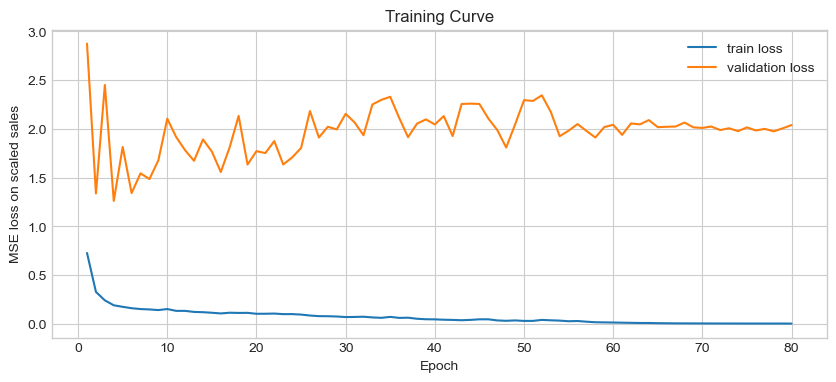

In [16]:
# -----------------------------------------------------------------------------
# This cell plots training loss and validation loss.
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history_df["epoch"], history_df["train_loss"], label="train loss")
ax.plot(history_df["epoch"], history_df["val_loss"], label="validation loss")
ax.set_title("Training Curve")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss on scaled sales")
ax.legend()
plt.show()


### Findings From the Loss Chart

- Training loss drops from **0.7266** to **0.0024**.
- Validation loss improves early and reaches its best shown value around epoch 20: **1.7710**.
- After that, validation loss stays around 2.0 while training loss keeps falling.
- This means the model learns the training windows very well, but it starts to overfit.


### What to Check in the Loss Chart

Training loss should go down.

Validation loss tells us how well the model works on unseen future data.

If training loss keeps going down but validation loss stops improving, the model may be overfitting.


## 13. Evaluate on the Test Set

For test prediction, we do not use teacher forcing.

That means:

```text
y = None
teacher_forcing_ratio = 0.0
```

The decoder must use its own previous predictions.


In [17]:
# -----------------------------------------------------------------------------
# This cell runs test prediction and compares Seq2Seq with baselines.
# -----------------------------------------------------------------------------
def predict_dataset(model, dataset):
    model.eval()
    x_all, y_all = collect_dataset_tensors(dataset)

    with torch.no_grad():
        pred_scaled = model(x_all, y=None, teacher_forcing_ratio=0.0)

    # Convert back to sales units before scoring.
    y_actual = inverse_sales(y_all.numpy())
    y_pred = inverse_sales(pred_scaled.numpy())
    return y_actual, y_pred


y_test_actual, seq2seq_pred = predict_dataset(model, test_dataset)

seq2seq_scores = pd.DataFrame({
    "model": ["seq2seq_gru"],
    "MAE": [mae(y_test_actual, seq2seq_pred)],
    "RMSE": [rmse(y_test_actual, seq2seq_pred)],
})

all_scores = pd.concat([baseline_scores, seq2seq_scores], ignore_index=True)
all_scores.sort_values("MAE")


,model,MAE,RMSE
1,seasonal_naive,5.664824,7.459758
3,seq2seq_gru,8.417038,9.322998
2,moving_average_7,8.456865,9.601283
0,naive,11.046169,13.436134


### Findings From Final Test Scores

- `seasonal_naive` is still best with **MAE = 5.66**.
- `seq2seq_gru` gets **MAE = 8.42** and **RMSE = 9.32**.
- Seq2Seq is slightly better than `moving_average_7`, but it does not beat `seasonal_naive`.
- Main takeaway: a deep learning model must be compared with simple baselines. Here, the simple weekly baseline is very strong.


## 14. Check Error for Each Future Day

One average error is not enough.

For a 7-day forecast, check each step:

```text
t+1, t+2, ..., t+7
```

This shows which future days are easy or hard for the model.


In [18]:
# -----------------------------------------------------------------------------
# This cell calculates error for each forecast step.
# -----------------------------------------------------------------------------
# (test_windows, horizon, target)
# 12 test examples
# 7 forecast days
# 1 target column: sales
# axis 0 = test windows
# axis 2 = target column
horizon_mae = np.mean(np.abs(y_test_actual - seq2seq_pred), axis=(0, 2))

horizon_error_df = pd.DataFrame({
    "horizon_step": [f"t+{i}" for i in range(1, HORIZON + 1)],
    "MAE": horizon_mae,
})

horizon_error_df


,horizon_step,MAE
0,t+1,9.464744
1,t+2,9.601436
2,t+3,9.921357
3,t+4,8.704411
4,t+5,7.542106
5,t+6,6.914447
6,t+7,6.770765


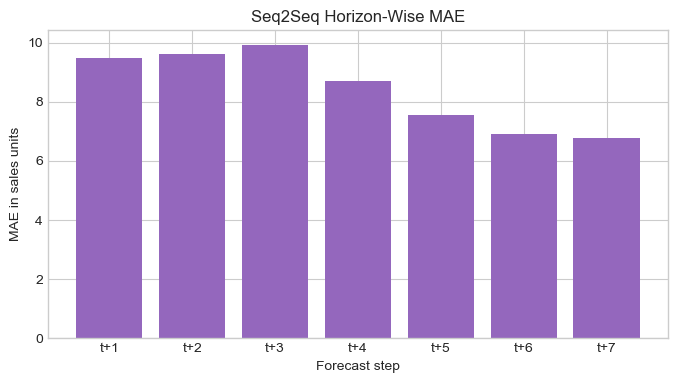

In [19]:
# -----------------------------------------------------------------------------
# This cell plots horizon-wise MAE.
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(horizon_error_df["horizon_step"], horizon_error_df["MAE"], color="#9467bd")
ax.set_title("Seq2Seq Horizon-Wise MAE")
ax.set_xlabel("Forecast step")
ax.set_ylabel("MAE in sales units")
plt.show()


### Findings From Horizon-Wise Error

- The highest error is at **t+3**, with **MAE = 9.92**.
- The lowest error is at **t+7**, with **MAE = 6.77**.
- Error does not simply increase as the forecast goes farther into the future.
- This means some specific future days are harder than others, likely because of sharper changes in sales.


### What to Check in the Horizon Error Chart

Look at which future step has the highest error.

Sometimes `t+1` is best and `t+7` is worst.

But not always. If one day has a spike or sudden change, that step may have higher error.


## 15. Plot One 7-Day Forecast

Now we plot one test example.

The plot shows:

- Previous 21 days used as input
- Actual next 7 days
- Predicted next 7 days

This is the easiest way to see what the model is doing.


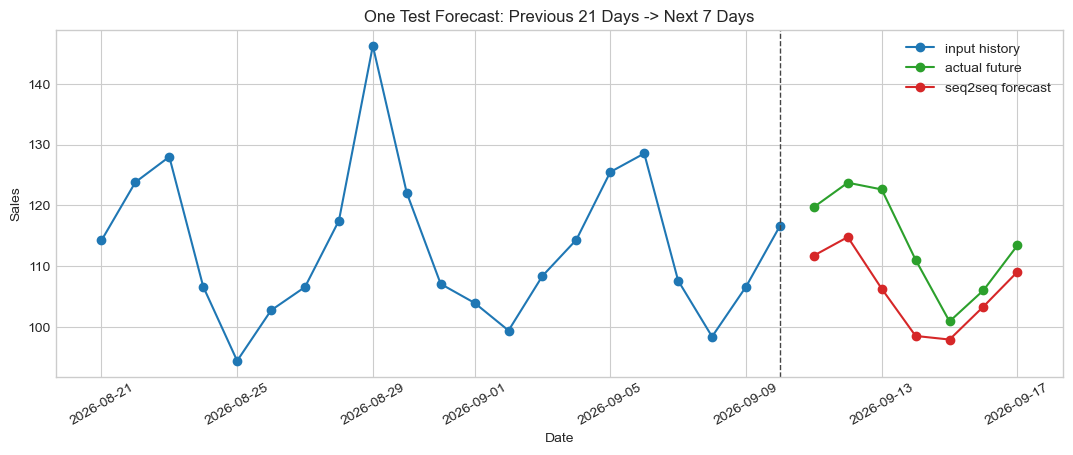

,date,actual_sales,predicted_sales,absolute_error
0,2026-09-11,119.712051,111.737770,7.974281
1,2026-09-12,123.721313,114.785233,8.936081
2,2026-09-13,122.618362,106.300896,16.317467
3,2026-09-14,111.049667,98.533401,12.516266
4,2026-09-15,100.917564,97.941116,2.976448
5,2026-09-16,106.036804,103.364380,2.672424
6,2026-09-17,113.403900,109.062851,4.341049


In [20]:
# -----------------------------------------------------------------------------
# This cell plots one example forecast from the test set.
# -----------------------------------------------------------------------------
example_idx = len(test_dataset) - 1
x_example_scaled, y_example_scaled = test_dataset[example_idx]

model.eval()
with torch.no_grad():
    pred_example_scaled = model(x_example_scaled.unsqueeze(0), y=None, teacher_forcing_ratio=0.0).squeeze(0).numpy()

x_sales = inverse_sales(x_example_scaled[:, target_col_index].numpy())
y_actual = inverse_sales(y_example_scaled[:, 0].numpy())
y_pred = inverse_sales(pred_example_scaled[:, 0])

input_start = example_idx
input_end = example_idx + LOOKBACK
future_end = input_end + HORIZON

input_dates = test_df["date"].iloc[input_start:input_end]
future_dates = test_df["date"].iloc[input_end:future_end]

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(input_dates, x_sales, marker="o", label="input history", color="#1f77b4")
ax.plot(future_dates, y_actual, marker="o", label="actual future", color="#2ca02c")
ax.plot(future_dates, y_pred, marker="o", label="seq2seq forecast", color="#d62728")
ax.axvline(input_dates.iloc[-1], color="#444444", linestyle="--", linewidth=1)
ax.set_title("One Test Forecast: Previous 21 Days -> Next 7 Days")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
ax.legend()
plt.xticks(rotation=30)
plt.show()

pd.DataFrame({
    "date": future_dates.values,
    "actual_sales": y_actual,
    "predicted_sales": y_pred,
    "absolute_error": np.abs(y_actual - y_pred),
})


### Findings From the Example Forecast

- The forecast follows the general sales level, but it is smoother than the actual sales line.
- The model underpredicts the first four future days.
- The largest error is on **2026-09-13**, with an absolute error of about **16.32** sales units.
- The last three days are closer, with errors around **2.67 to 4.34** sales units.
- This plot shows why one average score is not enough. We should also inspect individual forecasts.
